# Lineáris egyenletrendszerek és a Gauss-elimináció

Ez a notebook a **numerikus módszerek** kurzus 2. előadásának anyagát szemlélteti interaktív Python példákkal.

**Tartalom:**
1. Lineáris egyenletrendszerek (LER) alapjai
2. Gauss-elimináció lépésről lépésre
3. Gauss-elimináció implementáció
4. Részleges főelemkiválasztás
5. Alkalmazások: determináns, inverz mátrix
6. Műveletigény vizsgálat

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

np.set_printoptions(precision=4, suppress=True)

## 1. Lineáris egyenletrendszerek (LER)

Egy lineáris egyenletrendszer általános alakja:

$$
\begin{align}
a_{11}x_1 + a_{12}x_2 + \cdots + a_{1n}x_n &= b_1 \\
a_{21}x_1 + a_{22}x_2 + \cdots + a_{2n}x_n &= b_2 \\
&\vdots \\
a_{n1}x_1 + a_{n2}x_2 + \cdots + a_{nn}x_n &= b_n
\end{align}
$$

Mátrix alakban: $A \cdot x = b$, ahol $A \in \mathbb{R}^{n \times n}$, $b, x \in \mathbb{R}^n$.

**Feladat:** $A$ és $b$ adottak, keressük $x$-et.

### 1.1 Példa: A MATEK fejtörő

A MATEK szó minden betűje egy-egy számjegyet jelöl:

$$
\begin{align}
M + A + T + E + K &= 25 \\
M + A &= 11 \\
A + T &= 10 \\
T + E &= 12 \\
E + K &= 10
\end{align}
$$

Melyik betű melyik számjegyet jelöli?

In [2]:
# A MATEK fejtörő mint lineáris egyenletrendszer
# Változók sorrendje: M, A, T, E, K

A_matek = np.array([
    [1, 1, 1, 1, 1],  # M + A + T + E + K = 25
    [1, 1, 0, 0, 0],  # M + A = 11
    [0, 1, 1, 0, 0],  # A + T = 10
    [0, 0, 1, 1, 0],  # T + E = 12
    [0, 0, 0, 1, 1],  # E + K = 10
], dtype=float)

b_matek = np.array([25, 11, 10, 12, 10], dtype=float)

x_matek = np.linalg.solve(A_matek, b_matek)

print("Megoldás:")
for nev, ertek in zip(['M', 'A', 'T', 'E', 'K'], x_matek):
    print(f"  {nev} = {ertek:.0f}")

Megoldás:
  M = 5
  A = 6
  T = 4
  E = 8
  K = 2


## 2. Gauss-elimináció lépésről lépésre

A Gauss-elimináció (GE) két fő lépésből áll:
1. **Előre (elimináció):** a főátló alatt kinullázzuk az elemeket → felső háromszög mátrix
2. **Vissza (visszahelyettesítés):** a felső háromszög alakú LER-t megoldjuk

A kibővített mátrix jelölése: $[A|b]$

### Példa az előadásból

$$
\begin{bmatrix} 2 & 0 & 3 \\ -4 & 5 & -2 \\ 6 & -5 & 4 \end{bmatrix} \cdot x = \begin{bmatrix} -1 \\ 3 \\ -3 \end{bmatrix}
$$

In [3]:
def print_augmented(Ab, step_label=""):
    """Kibővített mátrix szép kiírása."""
    n = Ab.shape[0]
    if step_label:
        print(f"--- {step_label} ---")
    for i in range(n):
        row_A = "  ".join(f"{Ab[i,j]:7.2f}" for j in range(n))
        row_b = "  ".join(f"{Ab[i,j]:7.2f}" for j in range(n, Ab.shape[1]))
        print(f"  [{row_A}  | {row_b}]")
    print()

In [4]:
# A példa mátrix és jobboldal
A = np.array([[2, 0, 3],
              [-4, 5, -2],
              [6, -5, 4]], dtype=float)
b = np.array([-1, 3, -3], dtype=float)

# Kibővített mátrix
Ab = np.column_stack([A.copy(), b.copy()])
print_augmented(Ab, "Kiindulás: [A|b]")

--- Kiindulás: [A|b] ---
  [   2.00     0.00     3.00  |   -1.00]
  [  -4.00     5.00    -2.00  |    3.00]
  [   6.00    -5.00     4.00  |   -3.00]



In [5]:
# === ELIMINÁCIÓ: 1. LÉPÉS ===
# A főátló alatti elemeket kinullázzuk az 1. oszlopban

Ab = np.column_stack([A.copy(), b.copy()])  # friss másolat

# 2. sor -= (-4/2) * 1. sor  →  szorzó = -4/2 = -2, tehát 2. sor += 2 * 1.sor
m21 = Ab[1, 0] / Ab[0, 0]
print(f"1. lépés:")
print(f"  2. sor -= ({Ab[1,0]:.0f}/{Ab[0,0]:.0f}) * 1. sor   (szorzó = {m21:.1f})")
Ab[1] = Ab[1] - m21 * Ab[0]

# 3. sor -= (6/2) * 1. sor  →  szorzó = 6/2 = 3
m31 = Ab[2, 0] / Ab[0, 0]
print(f"  3. sor -= ({A[2,0]:.0f}/{A[0,0]:.0f}) * 1. sor   (szorzó = {m31:.1f})")
Ab[2] = Ab[2] - m31 * Ab[0]

print()
print_augmented(Ab, "1. lépés után")

1. lépés:
  2. sor -= (-4/2) * 1. sor   (szorzó = -2.0)
  3. sor -= (6/2) * 1. sor   (szorzó = 3.0)

--- 1. lépés után ---
  [   2.00     0.00     3.00  |   -1.00]
  [   0.00     5.00     4.00  |    1.00]
  [   0.00    -5.00    -5.00  |    0.00]



In [6]:
# === ELIMINÁCIÓ: 2. LÉPÉS ===
# A főátló alatti elemeket kinullázzuk a 2. oszlopban

m32 = Ab[2, 1] / Ab[1, 1]
print(f"2. lépés:")
print(f"  3. sor -= ({Ab[2,1]:.0f}/{Ab[1,1]:.0f}) * 2. sor   (szorzó = {m32:.1f})")
Ab[2] = Ab[2] - m32 * Ab[1]

print()
print_augmented(Ab, "2. lépés után (felső háromszög alak)")

2. lépés:
  3. sor -= (-5/5) * 2. sor   (szorzó = -1.0)

--- 2. lépés után (felső háromszög alak) ---
  [   2.00     0.00     3.00  |   -1.00]
  [   0.00     5.00     4.00  |    1.00]
  [   0.00     0.00    -1.00  |    1.00]



In [7]:
# === VISSZAHELYETTESÍTÉS ===
n = 3
x = np.zeros(n)

print("Visszahelyettesítés:")

# x3 = a_{3,4} / a_{3,3}
x[2] = Ab[2, 3] / Ab[2, 2]
print(f"  x3 = {Ab[2,3]:.1f} / {Ab[2,2]:.1f} = {x[2]:.1f}")

# x2 = (a_{2,4} - a_{2,3}*x3) / a_{2,2}
x[1] = (Ab[1, 3] - Ab[1, 2] * x[2]) / Ab[1, 1]
print(f"  x2 = ({Ab[1,3]:.1f} - {Ab[1,2]:.1f}*{x[2]:.1f}) / {Ab[1,1]:.1f} = {x[1]:.1f}")

# x1 = (a_{1,4} - a_{1,2}*x2 - a_{1,3}*x3) / a_{1,1}
x[0] = (Ab[0, 3] - Ab[0, 1] * x[1] - Ab[0, 2] * x[2]) / Ab[0, 0]
print(f"  x1 = ({Ab[0,3]:.1f} - {Ab[0,1]:.1f}*{x[1]:.1f} - {Ab[0,2]:.1f}*{x[2]:.1f}) / {Ab[0,0]:.1f} = {x[0]:.1f}")

print(f"\nMegoldás: x = {x}")
print(f"Ellenőrzés (A@x = b): {np.allclose(A @ x, b)}")

Visszahelyettesítés:
  x3 = 1.0 / -1.0 = -1.0
  x2 = (1.0 - 4.0*-1.0) / 5.0 = 1.0
  x1 = (-1.0 - 0.0*1.0 - 3.0*-1.0) / 2.0 = 1.0

Megoldás: x = [ 1.  1. -1.]
Ellenőrzés (A@x = b): True


## 3. Gauss-elimináció implementáció

A Gauss-elimináció $k$-adik lépésének általános képlete:

$$
a_{ij}^{(k)} = a_{ij}^{(k-1)} - \frac{a_{ik}^{(k-1)}}{a_{kk}^{(k-1)}} \cdot a_{kj}^{(k-1)}
$$

ahol $k = 1, \ldots, n-1$; $i = k+1, \ldots, n$; $j = k+1, \ldots, n, n+1$.

In [8]:
def gauss_elimination(A, b, verbose=False):
    """
    Lineáris egyenletrendszer megoldása Gauss-eliminációval.
    
    Paraméterek:
        A: n×n együttható mátrix
        b: n hosszú jobboldali vektor
        verbose: ha True, kiírja a lépéseket
    
    Visszatérési érték:
        x: a megoldásvektor
    """
    n = len(b)
    # Kibővített mátrix
    Ab = np.column_stack([A.astype(float), b.astype(float)])
    
    if verbose:
        print_augmented(Ab, "Kiindulás")
    
    # --- Előre: elimináció ---
    for k in range(n - 1):
        if Ab[k, k] == 0:
            raise ValueError(f"Nulla pivot a {k+1}. lépésben! Főelemkiválasztás szükséges.")
        for i in range(k + 1, n):
            m = Ab[i, k] / Ab[k, k]  # szorzó
            Ab[i, k:] = Ab[i, k:] - m * Ab[k, k:]
            if verbose:
                print(f"  {i+1}. sor -= {m:.4f} * {k+1}. sor")
        if verbose:
            print_augmented(Ab, f"{k+1}. lépés után")
    
    # --- Vissza: visszahelyettesítés ---
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (Ab[i, n] - np.dot(Ab[i, i+1:n], x[i+1:n])) / Ab[i, i]
    
    return x

In [9]:
# Tesztelés a PDF példáján
A = np.array([[2, 0, 3],
              [-4, 5, -2],
              [6, -5, 4]], dtype=float)
b = np.array([-1, 3, -3], dtype=float)

x = gauss_elimination(A, b, verbose=True)
print(f"Megoldás: x = {x}")
print(f"Elvárt:   x = [ 1.  1. -1.]")
print(f"Helyes:   {np.allclose(A @ x, b)}")

--- Kiindulás ---
  [   2.00     0.00     3.00  |   -1.00]
  [  -4.00     5.00    -2.00  |    3.00]
  [   6.00    -5.00     4.00  |   -3.00]

  2. sor -= -2.0000 * 1. sor
  3. sor -= 3.0000 * 1. sor
--- 1. lépés után ---
  [   2.00     0.00     3.00  |   -1.00]
  [   0.00     5.00     4.00  |    1.00]
  [   0.00    -5.00    -5.00  |    0.00]

  3. sor -= -1.0000 * 2. sor
--- 2. lépés után ---
  [   2.00     0.00     3.00  |   -1.00]
  [   0.00     5.00     4.00  |    1.00]
  [   0.00     0.00    -1.00  |    1.00]

Megoldás: x = [ 1.  1. -1.]
Elvárt:   x = [ 1.  1. -1.]
Helyes:   True


## 4. Részleges főelemkiválasztás

Ha a pivot elem (a főátlóbeli elem, amivel osztunk) nulla vagy nagyon kicsi, a GE elromolhat.

**Részleges főelemkiválasztás:** a $k$-adik lépésben a $k$-adik oszlop $k$-adik sorától lefelé megkeressük az abszolút értékben legnagyobb elemet, és kicseréljük a $k$-adik sort ezzel a sorral.

### Példa: nulla pivot

In [10]:
# Nulla pivot esete
A_nulla = np.array([[0, 1],
                    [1, 0]], dtype=float)
b_nulla = np.array([2, 3], dtype=float)

print("A mátrix:")
print(A_nulla)
print(f"b = {b_nulla}")
print()

try:
    x = gauss_elimination(A_nulla, b_nulla)
except ValueError as e:
    print(f"Hiba: {e}")
    print("→ Főelemkiválasztás szükséges!")

A mátrix:
[[0. 1.]
 [1. 0.]]
b = [2. 3.]

Hiba: Nulla pivot a 1. lépésben! Főelemkiválasztás szükséges.
→ Főelemkiválasztás szükséges!


In [11]:
def gauss_elimination_pivot(A, b, verbose=False):
    """
    Gauss-elimináció részleges főelemkiválasztással.
    """
    n = len(b)
    Ab = np.column_stack([A.astype(float), b.astype(float)])
    
    if verbose:
        print_augmented(Ab, "Kiindulás")
    
    for k in range(n - 1):
        # Részleges főelemkiválasztás: legnagyobb abszolút értékű elem keresése
        max_idx = np.argmax(np.abs(Ab[k:n, k])) + k
        if Ab[max_idx, k] == 0:
            raise ValueError("Szinguláris mátrix!")
        
        if max_idx != k:
            Ab[[k, max_idx]] = Ab[[max_idx, k]]  # sorcsere
            if verbose:
                print(f"  Sorcsere: {k+1}. sor <-> {max_idx+1}. sor")
                print_augmented(Ab, "Sorcsere után")
        
        for i in range(k + 1, n):
            m = Ab[i, k] / Ab[k, k]
            Ab[i, k:] = Ab[i, k:] - m * Ab[k, k:]
            if verbose:
                print(f"  {i+1}. sor -= {m:.4f} * {k+1}. sor")
        if verbose:
            print_augmented(Ab, f"{k+1}. lépés után")
    
    # Visszahelyettesítés
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (Ab[i, n] - np.dot(Ab[i, i+1:n], x[i+1:n])) / Ab[i, i]
    
    return x

In [12]:
# Most már működik a nulla pivottal is
x = gauss_elimination_pivot(A_nulla, b_nulla, verbose=True)
print(f"Megoldás: x = {x}")
print(f"Ellenőrzés: {np.allclose(A_nulla @ x, b_nulla)}")

--- Kiindulás ---
  [   0.00     1.00  |    2.00]
  [   1.00     0.00  |    3.00]

  Sorcsere: 1. sor <-> 2. sor
--- Sorcsere után ---
  [   1.00     0.00  |    3.00]
  [   0.00     1.00  |    2.00]

  2. sor -= 0.0000 * 1. sor
--- 1. lépés után ---
  [   1.00     0.00  |    3.00]
  [   0.00     1.00  |    2.00]

Megoldás: x = [3. 2.]
Ellenőrzés: True


In [13]:
# Tesztelés az eredeti 3×3 példán is
A = np.array([[2, 0, 3],
              [-4, 5, -2],
              [6, -5, 4]], dtype=float)
b = np.array([-1, 3, -3], dtype=float)

x = gauss_elimination_pivot(A, b, verbose=True)
print(f"Megoldás: x = {x}")
print(f"Helyes:   {np.allclose(A @ x, b)}")

--- Kiindulás ---
  [   2.00     0.00     3.00  |   -1.00]
  [  -4.00     5.00    -2.00  |    3.00]
  [   6.00    -5.00     4.00  |   -3.00]

  Sorcsere: 1. sor <-> 3. sor
--- Sorcsere után ---
  [   6.00    -5.00     4.00  |   -3.00]
  [  -4.00     5.00    -2.00  |    3.00]
  [   2.00     0.00     3.00  |   -1.00]

  2. sor -= -0.6667 * 1. sor
  3. sor -= 0.3333 * 1. sor
--- 1. lépés után ---
  [   6.00    -5.00     4.00  |   -3.00]
  [   0.00     1.67     0.67  |    1.00]
  [   0.00     1.67     1.67  |    0.00]

  3. sor -= 1.0000 * 2. sor
--- 2. lépés után ---
  [   6.00    -5.00     4.00  |   -3.00]
  [   0.00     1.67     0.67  |    1.00]
  [   0.00     0.00     1.00  |   -1.00]

Megoldás: x = [ 1.  1. -1.]
Helyes:   True


## 5. Alkalmazások

### 5.1 Determináns számítása GE-vel

A GE átalakításai determináns tartók, ezért:

$$
\det(A) = \det(\Delta\text{alak}) = \prod_{k=1}^{n} a_{kk}^{(k-1)}
$$

Vigyázat: sorcsere esetén a determináns előjelet vált!

In [14]:
def det_gauss(A):
    """Determináns számítása Gauss-eliminációval."""
    n = A.shape[0]
    M = A.astype(float).copy()
    sign = 1  # sorcserék előjelváltása
    
    for k in range(n - 1):
        # Részleges főelemkiválasztás
        max_idx = np.argmax(np.abs(M[k:n, k])) + k
        if M[max_idx, k] == 0:
            return 0.0  # szinguláris
        if max_idx != k:
            M[[k, max_idx]] = M[[max_idx, k]]
            sign *= -1  # sorcsere előjelet vált
        for i in range(k + 1, n):
            m = M[i, k] / M[k, k]
            M[i, k:] -= m * M[k, k:]
    
    # A főátló elemeinek szorzata
    det = sign * np.prod(np.diag(M))
    return det

In [15]:
A = np.array([[2, 0, 3],
              [-4, 5, -2],
              [6, -5, 4]], dtype=float)

det_ge = det_gauss(A)
det_np = np.linalg.det(A)

print(f"Determináns (GE):     {det_ge:.1f}")
print(f"Determináns (numpy):  {det_np:.1f}")
print(f"Elvárt:               -10.0")

Determináns (GE):     -10.0
Determináns (numpy):  -10.0
Elvárt:               -10.0


### 5.2 Inverz mátrix számítása GE-vel

Az $A \cdot X = I$ mátrixegyenletet oldjuk meg:

$$
[A \mid I] \xrightarrow{\text{GE}} \xrightarrow{\text{visszahely.}} [I \mid A^{-1}]
$$

Ezt úgy valósítjuk meg, hogy a kibővített mátrixban $b$ helyett az egységmátrix oszlopait rakjuk.

In [16]:
def inv_gauss(A):
    """Inverz mátrix számítása Gauss-eliminációval."""
    n = A.shape[0]
    # [A | I] kibővített mátrix
    AI = np.column_stack([A.astype(float), np.eye(n)])
    
    # Előre: elimináció részleges főelemkiválasztással
    for k in range(n):
        max_idx = np.argmax(np.abs(AI[k:n, k])) + k
        if AI[max_idx, k] == 0:
            raise ValueError("Szinguláris mátrix, nincs inverze!")
        if max_idx != k:
            AI[[k, max_idx]] = AI[[max_idx, k]]
        
        # A pivot sor normálása
        AI[k] = AI[k] / AI[k, k]
        
        # Elimináció minden más sorból (Gauss-Jordan)
        for i in range(n):
            if i != k:
                m = AI[i, k]
                AI[i] -= m * AI[k]
    
    return AI[:, n:]  # a jobb oldal az inverz

In [17]:
A = np.array([[2, 0, 3],
              [-4, 5, -2],
              [6, -5, 4]], dtype=float)

A_inv_ge = inv_gauss(A)
A_inv_np = np.linalg.inv(A)

print("Inverz (GE):")
print(A_inv_ge)
print("\nInverz (numpy):")
print(A_inv_np)
print(f"\nEgyeznek: {np.allclose(A_inv_ge, A_inv_np)}")
print(f"\nEllenőrzés (A @ A_inv ≈ I): {np.allclose(A @ A_inv_ge, np.eye(3))}")

Inverz (GE):
[[-1.   1.5  1.5]
 [-0.4  1.   0.8]
 [ 1.  -1.  -1. ]]

Inverz (numpy):
[[-1.   1.5  1.5]
 [-0.4  1.   0.8]
 [ 1.  -1.  -1. ]]

Egyeznek: True

Ellenőrzés (A @ A_inv ≈ I): True


## 6. Műveletigény vizsgálat

A Gauss-elimináció műveletigénye:

$$
\frac{2}{3}n^3 + \mathcal{O}(n^2)
$$

A visszahelyettesítés műveletigénye: $n^2 + \mathcal{O}(n)$.

Vizsgáljuk meg, hogy a futási idő valóban $n^3$-ösen nő-e!

In [18]:
# === Műveletszámlálás: pontos ellenőrzése a 2/3 n³ képletnek ===

def gauss_elimination_count(A, b):
    """GE műveletszámlálással (osztás, szorzás, összeadás)."""
    n = len(b)
    Ab = np.column_stack([A.astype(float), b.astype(float)])
    ops = 0  # lebegőpontos műveletek száma
    
    for k in range(n - 1):
        for i in range(k + 1, n):
            ops += 1  # osztás: m = Ab[i,k] / Ab[k,k]
            m = Ab[i, k] / Ab[k, k]
            for j in range(k + 1, n + 1):
                ops += 2  # 1 szorzás + 1 kivonás
                Ab[i, j] = Ab[i, j] - m * Ab[k, j]
    
    # Visszahelyettesítés
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        s = Ab[i, n]
        for j in range(i + 1, n):
            ops += 2  # 1 szorzás + 1 kivonás
            s -= Ab[i, j] * x[j]
        ops += 1  # osztás
        x[i] = s / Ab[i, i]
    
    return x, ops

# Tisztán duplázó méretsorozat: minden szomszédos pár 2-szeres
test_sizes = [5, 10, 20, 40, 80, 160]
measured_ops = []

print(f"{'n':>5} {'Mért ops':>12} {'2/3·n³+n²':>12} {'eltérés':>10}")
print("-" * 42)
for n in test_sizes:
    A_rand = np.random.randn(n, n)
    b_rand = np.random.randn(n)
    _, ops = gauss_elimination_count(A_rand, b_rand)
    
    theory = int(2/3*n**3 + n**2)
    diff_pct = (ops - theory) / theory * 100
    
    measured_ops.append(ops)
    print(f"{n:>5} {ops:>12} {theory:>12} {diff_pct:>+9.1f}%")

measured_ops = np.array(measured_ops)
test_sizes = np.array(test_sizes)

    n     Mért ops    2/3·n³+n²    eltérés
------------------------------------------
    5          115          108      +6.5%
   10          805          766      +5.1%
   20         5910         5733      +3.1%
   40        45020        44266      +1.7%


   80       350840       347733      +0.9%


  160      2768880      2756266      +0.5%


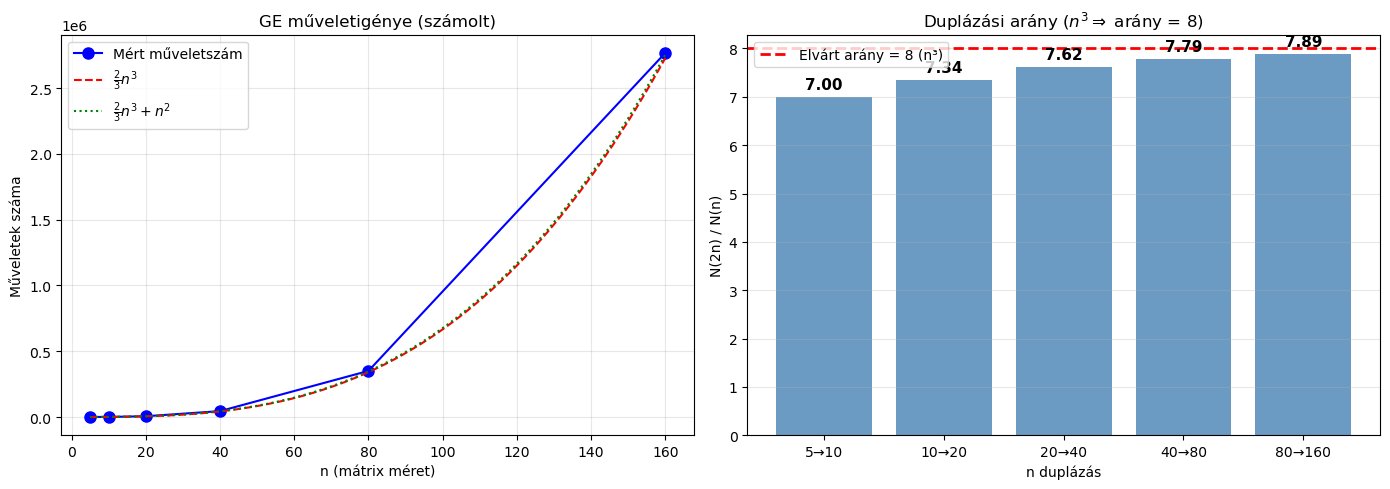

In [19]:
# Műveletigény vizualizáció
n_fine = np.linspace(5, 160, 200)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bal: műveletszám vs 2/3 n³
axes[0].plot(test_sizes, measured_ops, 'bo-', markersize=8, label='Mért műveletszám')
axes[0].plot(n_fine, 2/3 * n_fine**3, 'r--', label=r'$\frac{2}{3} n^3$')
axes[0].plot(n_fine, 2/3 * n_fine**3 + n_fine**2, 'g:', label=r'$\frac{2}{3} n^3 + n^2$')
axes[0].set_xlabel('n (mátrix méret)')
axes[0].set_ylabel('Műveletek száma')
axes[0].set_title('GE műveletigénye (számolt)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Jobb: duplázási arány — minden szomszédos pár 2x (5→10, 10→20, 20→40, ...)
ratios = measured_ops[1:] / measured_ops[:-1]
exponents = np.log2(ratios)
size_labels = [f"{test_sizes[i]}\u2192{test_sizes[i+1]}" for i in range(len(test_sizes)-1)]

bars = axes[1].bar(size_labels, ratios, color='steelblue', alpha=0.8)
axes[1].axhline(y=8.0, color='r', linestyle='--', linewidth=2, label='Elvárt arány = 8 (n³)')
axes[1].set_xlabel('n duplázás')
axes[1].set_ylabel('N(2n) / N(n)')
axes[1].set_title(r'Duplázási arány ($n^3 \Rightarrow$ arány = 8)')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# Értékek kiírása az oszlopokra
for bar, r in zip(bars, ratios):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{r:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [20]:
# Duplázási arány táblázat
# test_sizes = [5, 10, 20, 40, 80, 160] → minden szomszédos pár duplázás

print("n³ skálázás ellenőrzése a műveletszám alapján:")
print("Ha N(n) ~ n³, akkor N(2n)/N(n) = 8 (pontosan).")
print()
print(f"{'n':>6} {'2n':>6} {'N(n)':>12} {'N(2n)':>12} {'N(2n)/N(n)':>12}")
print("-" * 52)
for i in range(len(test_sizes) - 1):
    n1 = test_sizes[i]
    n2 = test_sizes[i + 1]
    ratio = measured_ops[i + 1] / measured_ops[i]
    print(f"{n1:>6} {n2:>6} {measured_ops[i]:>12} {measured_ops[i+1]:>12} {ratio:>12.2f}")

print()
print("Az arány nagy n-re 8-hoz konvergál, mert N(n) = 2/3·n³ + O(n²),")
print("és a kis n-eknél az O(n²) tag még számottevő.")

n³ skálázás ellenőrzése a műveletszám alapján:
Ha N(n) ~ n³, akkor N(2n)/N(n) = 8 (pontosan).

     n     2n         N(n)        N(2n)   N(2n)/N(n)
----------------------------------------------------
     5     10          115          805         7.00
    10     20          805         5910         7.34
    20     40         5910        45020         7.62
    40     80        45020       350840         7.79
    80    160       350840      2768880         7.89

Az arány nagy n-re 8-hoz konvergál, mert N(n) = 2/3·n³ + O(n²),
és a kis n-eknél az O(n²) tag még számottevő.


## Összefoglalás

| Téma | Lényeg |
|------|--------|
| **LER** | $Ax = b$, $n$ egyenlet, $n$ ismeretlen |
| **Gauss-elimináció** | Előre (elimináció) + Vissza (visszahelyettesítés) |
| **Főelemkiválasztás** | Nulla/kicsi pivot elkerülése, numerikus stabilitás |
| **Determináns** | GE után a főátló elemeinek szorzata |
| **Inverz** | $[A \mid I] \Rightarrow [I \mid A^{-1}]$ Gauss-Jordan eliminációval |
| **Műveletigény** | GE: $\frac{2}{3}n^3 + \mathcal{O}(n^2)$, visszahely.: $n^2 + \mathcal{O}(n)$ |